### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator, FuncFormatter
from fractions import Fraction
import math

### Utility functions

In [2]:
# Get colormap values
def get_cmap_vals(n,cmap='viridis'):
    '''
    Function to create a colormap (in hex) with a n distinct colors based on the colormap viridis.
    '''
    cmap = plt.get_cmap(cmap)
    colors = [cmap(i / (n - 1)) for i in range(n)]
    hex_colors = [mcolors.rgb2hex(color[:3]) for color in colors]
    return hex_colors

# Define the function to format ticks dynamically
def pi_formatter(x, pos):
    frac = Fraction(x / np.pi).limit_denominator(16)  # Limit denominator to avoid overly complex fractions
    if frac.numerator == 0:
        return "0"
    elif frac.denominator == 1:
        return r"${}\pi$".format(frac.numerator)
    elif frac.numerator == 1:
        return r"$\frac{{\pi}}{{{}}}$".format(frac.denominator)
    else:
        return r"$\frac{{{}\pi}}{{{}}}$".format(frac.numerator, frac.denominator)

def change_spines(ax,vals=[False,False,True,True]):
    ax.spines['top'].set_visible(vals[0])
    ax.spines['right'].set_visible(vals[1])
    ax.spines['bottom'].set_visible(vals[2])
    ax.spines['left'].set_visible(vals[3])

def change_visuals(ax,labels,axs,theta):
    # Change facecolor
    ax.set_facecolor('None')

    # Set axis limits
    ax.set_xlim(min(theta),max(theta))

    # Change borders
    change_spines(ax=ax,vals=[False,False,True,True])

    # Change x-axis tick labels to radians
    ax.xaxis.set_major_locator(MultipleLocator(np.pi / 16))
    ax.xaxis.set_major_formatter(FuncFormatter(pi_formatter))

    # Calculate height of the ax object
    ax_height = ax.figure.get_figheight() * ax.get_position().height

    # Set legend height to match the height of ax object
    handle_heigth = ax_height*0.6
   
    # Create custom legend handles as rectangles
    legend_handles = [mpatches.Rectangle((0, 0), 1, 1, fc=line.get_color()) for line in axs]
    # Adjust the legend to appear slightly further outside the plot
    ax.legend(legend_handles, labels, title=r'$\lambda$', handleheight=handle_heigth, handletextpad=0.0, loc='center left', bbox_to_anchor=(1.01, 0.5), borderaxespad=0.0, fontsize=10,frameon=True)

## Plotting the coincidence proability and Fischer Information together

The formula for the Fischer Information $\mathcal{F}(\vartheta)$ is
$$\begin{align*}
\mathcal{F}(\vartheta)=\sum_{i}\dfrac{1}{pi}\left(\dfrac{\partial p_i}{\partial \vartheta}\right)^2.
\end{align*}$$
From our calculations involving the TMSV, the resulting probabilies for the no-click and 1-click cases are:
$$\begin{align*}
P_{\text{no-click}}&=\Lambda^2\braket{0,0|0,0}=1-\lambda^2\\
P_{\text{1-click}}(\vartheta)&=2(1-\lambda^2)\left(\dfrac{1}{\sqrt{1-\lambda^2\sin^2(4\vartheta)}}-1\right)
\end{align*}$$
With the conditions that all probabilities add up to 1
$$\begin{align*}
1\overset{!}{=}P_{\text{no-click}}+P_{\text{1-click}}(\vartheta)+P_{\text{coinc.}}(\vartheta),
\end{align*}$$
We can also derive the probability for coincidences:
$$\begin{align*}
P_{\text{coinc.}}(\vartheta)=\lambda^2-2(1-\lambda^2)\left(\dfrac{1}{\sqrt{1-\lambda^2\sin^2(4\vartheta)}}-1\right)
\end{align*}$$
The derivatives of these probabilities are:
$$\begin{align*}
\dfrac{\partial P_{\text{no-click}}}{\partial \vartheta}&=0\\
\dfrac{\partial P_{\text{1-click}}}{\partial \vartheta}&= \dfrac{-8\lambda^2(1 - \lambda^2)\cos(4\vartheta)\sin(4\vartheta)}{\left(1 - \lambda^2 \sin^2(4\vartheta)\right)^{3/2}}
\\
\dfrac{\partial P_{\text{coinc.}}}{\partial \vartheta}&=-\dfrac{\partial P_{\text{1-click}}}{\partial \vartheta}=\dfrac{8\lambda^2(1 - \lambda^2)\cos(4\vartheta)\sin(4\vartheta)}{\left(1 - \lambda^2 \sin^2(4\vartheta)\right)^{3/2}}
\end{align*}$$

With the probabilities and their derivatives we can now calculate the Fischer Information $\mathcal{F}(\vartheta)$. This is handled by the code below.

### Probability Functions and Fischer Information

In [3]:
def single_prob(theta,l):
    return 2*(1-l**2)*(1/np.sqrt(1-l**2*np.sin(4*theta)**2)-1)
def cc_prob(theta,l):
    return l**2-single_prob(theta,l)
def derivate_cc_prob(theta, l):
    return 8*(1-l**2)*np.cos(4*theta)*np.sin(4*theta)/(1-l**2*np.sin(4*theta)**2)**(3/2)*l**2 # no "-" since the derivative will be squared anyway
def fischer_info(theta,l):
    return derivate_cc_prob(theta,l)**2/(1-l**2+single_prob(theta,l))+derivate_cc_prob(theta,l)**2/(l**2-single_prob(theta,l))

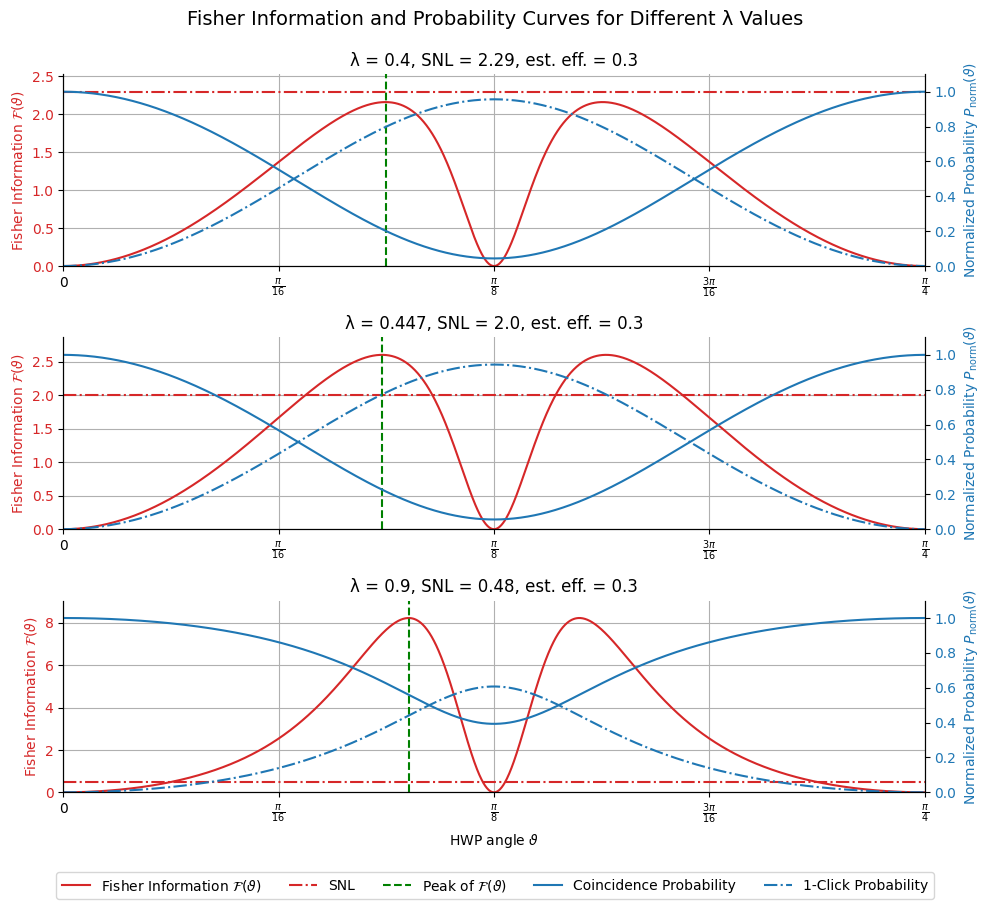

In [4]:
res = 1500
theta = np.linspace(0, 1 * np.pi / 4, res)
lambdas = [0.4, 0.447,0.9]

# Creating the figure with subplots (one column, multiple rows)
hstretch = 0.5
vstretch = 0.75
fig, axes = plt.subplots(
    nrows=len(lambdas),
    ncols=1,
    figsize=(20 * hstretch, 4 * vstretch * len(lambdas)),
    sharex=False
)

# Ensure axes is always iterable
if len(lambdas) == 1:
    axes = [axes]

# Initialize lists to collect legend handles and labels
all_handles = []
all_labels = []

for i, l in enumerate(lambdas):
    # Calculating curves
    cc_probs = 1 - single_prob(theta, l) / l**2
    c1_probs = single_prob(theta, l) / l**2
    estimated_eff = 0.95 * 0.95 * 0.33
    fischer = fischer_info(theta, l) * estimated_eff

    # Accessing the subplot axes
    ax1 = axes[i]
    ax2 = ax1.twinx()  # Create a twin y-axis

    # Plotting Fischer Information on ax1
    color1 = 'tab:red'
    line1, = ax1.plot(theta, fischer, color=color1, label=r"Fisher Information $\mathcal{F}(\vartheta)$")
    snl_value = 1 / np.sqrt(round(l**2 / (1 - l**2), 2))
    line2 = ax1.axhline(y=snl_value, color=color1, linestyle='-.', label="SNL")
    ax1.set_ylabel(r'Fisher Information $\mathcal{F}(\vartheta)$', color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    change_spines(ax1, [False, True, True, True])
    peak_theta = theta[np.argmax(fischer[1:int(res/2)]) + 1]
    line5 = ax1.axvline(x=peak_theta, color='g', linestyle="--", label=r"Peak of $\mathcal{F}(\vartheta)$")
    if fischer[np.argmax(fischer[1:int(res/2)])+1]>snl_value:
        ax1.set_ylim(0, fischer[np.argmax(fischer[1:int(res/2)])+1]*1.1)
    else:
        ax1.set_ylim(0, snl_value*1.1)
    ax1.grid()

    # Plotting probabilities on ax2
    color2 = 'tab:blue'
    line3, = ax2.plot(theta, cc_probs, color=color2, label="Coincidence Probability")
    line4, = ax2.plot(theta, c1_probs, color=color2, linestyle="-.", label="1-Click Probability")
    ax2.set_ylabel(r'Normalized Probability $P_{\mathrm{norm}}(\vartheta)$', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_ylim(0, 1.1)
    ax2.set_xlim(min(theta), max(theta))
    ax2.xaxis.set_major_locator(MultipleLocator(np.pi / 16))
    ax2.xaxis.set_major_formatter(FuncFormatter(pi_formatter))
    change_spines(ax2, [False, True, True, True])

    # Setting x-label only on the bottom subplot
    if i == len(lambdas)-1:
        ax1.set_xlabel(r'HWP angle $\vartheta$')

    # Setting subplot title
    ax1.set_title(
        f'λ = {l}, SNL = {round(snl_value, 2)}, est. eff. = {round(estimated_eff, 2)}'
    )

    # Collect legend handles and labels
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    all_handles.extend(handles1 + handles2)
    all_labels.extend(labels1 + labels2)

# Remove duplicate labels
unique_handles_labels = dict(zip(all_labels, all_handles))
unique_labels = list(unique_handles_labels.keys())
unique_handles = list(unique_handles_labels.values())

# Adjust layout and add overall title
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.suptitle('Fisher Information and Probability Curves for Different λ Values', fontsize=14)

# Add a single legend for the entire figure
fig.legend(
    unique_handles,
    unique_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.03),
    bbox_transform=fig.transFigure,
    ncol=5
)
plt.show()


### Coincidence probability

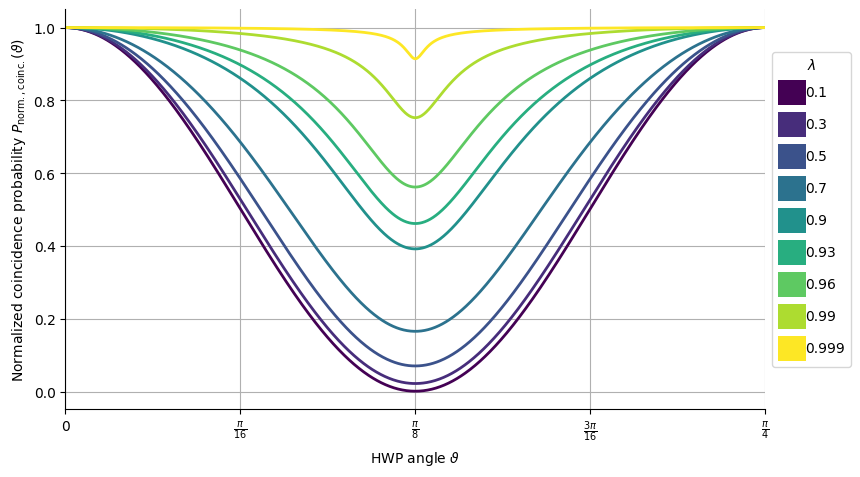

In [5]:
lambdas = np.asarray([0.1,0.3,0.5,0.7,0.9,0.93,0.96,0.99,0.999])
theta = np.linspace(0,np.pi/4,1000)

# Define the stretching factors
hstretch = 4.0
vstretch = 4.0

# Create a figure with a wider aspect ratio to add more white space on the right
fig = plt.figure(figsize=(15 * hstretch, 5 * vstretch))

# Create plots
ax = fig.add_axes([0, 0, hstretch * 1.75 / (15 * hstretch), vstretch * 1 / (5* vstretch)])
axs = []
cmap_vals = get_cmap_vals(len(lambdas))
for index,l in enumerate(lambdas):
    cc_probs = 1-single_prob(theta,l)/l**2
    ax_temp, = ax.plot(theta,cc_probs,color=cmap_vals[index],linewidth=2)
    axs.append(ax_temp)
change_visuals(ax,np.around(lambdas,3),axs,theta)
# Set labels & grid
ax.set_xlabel(r'HWP angle $\vartheta$')
ax.set_ylabel(r'Normalized coincidence probability $P_{\mathrm{norm.,coinc.}}(\vartheta)$')
ax.grid()
